# Phase 5: Multi-Experiment Model Training & Evaluation Pipeline
## Đề tài: Phát hiện và Giải thích Tấn công Mạng IoT (CICIoT2023) với XAI

> **Kiến trúc Quản lý Thử nghiệm theo từng Đợt (Experiment Tracking):**
> Mỗi đợt thử nghiệm (Run/Experiment) được đóng gói độc lập trong một thư mục riêng biệt theo chuẩn `THESIS_PLAN_RESULTS.md`, lưu trữ tường minh: thông số cấu hình (`config/`), phân bố dữ liệu & độ quan trọng đặc trưng (`data/`), trọng số mô hình (`model/`), các chỉ số & ma trận nhầm lẫn 8 lớp (`metrics/`), và nhật ký huấn luyện (`logs/`).

### Cấu trúc Thư mục Kết quả Thử nghiệm:
```text
phase5_experiments/
│
├── configs/                                 # Cấu hình tiền xử lý & lựa chọn đặc trưng
│   ├── preprocessing/preprocessing_v001.yaml
│   └── features/feature_selection_v001.yaml
│
├── exp_001_rf_baseline/                     # Đợt 1: Random Forest Baseline
│   ├── experiment.yaml                      # Tóm tắt định danh đợt thử nghiệm
│   ├── config/
│   │   ├── hyperparameters.yaml             # Siêu tham số mô hình
│   │   └── environment.yaml                 # Thông tin phiên bản môi trường
│   ├── data/
│   │   ├── class_distribution.json          # Số lượng mẫu từng lớp Train/Test
│   │   └── feature_importance.json          # Độ quan trọng 25 đặc trưng
│   ├── model/
│   │   ├── model.pkl & model.joblib         # Checkpoints nhị phân mô hình
│   │   └── training_config.yaml             # Cấu hình huấn luyện chi tiết
│   ├── metrics/
│   │   ├── classification_report.json       # Precision, Recall, F1 cho 8 lớp
│   │   ├── confusion_matrix.png             # Ma trận nhầm lẫn chuẩn Fig. 4a
│   │   └── metrics.json                     # Tổng hợp Accuracy, AUC, Macro F1
│   └── logs/
│       └── training.log                     # Nhật ký huấn luyện và thời gian
│
├── exp_002_xgboost_baseline/                # Đợt 2: Gradient Boosting Baseline
├── exp_003_decision_tree_baseline/          # Đợt 3: Decision Tree Baseline
├── exp_004_ensemble_blending_paper/         # Đợt 4: Proposed Ensemble Blending Model
├── exp_005_xgboost_tuned/                   # Đợt 5: XGBoost / Boosting Tinh chỉnh
│
├── comparison/                              # Bảng xếp hạng so sánh giữa các đợt
│   ├── leaderboard.csv                      # Bảng tổng hợp các chỉ số định lượng
│   ├── leaderboard.json                     # JSON format phục vụ tích hợp báo cáo
│   └── leaderboard_comparison.png           # Biểu đồ thanh so sánh trực quan
│
├── best_model/                              # Checkpoint mô hình dẫn đầu đợt thử nghiệm
│   ├── model.joblib
│   └── model_metadata.json
│
└── EXPERIMENTS_REGISTRY.yaml                # Sổ đăng ký trạng thái toàn bộ thử nghiệm
```

Sau khi hoàn tất, Phase 6 sẽ tiến hành kiểm định độc lập trên tập Validation & Test để lựa chọn mô hình tối ưu cho module XAI.

--- 
## Cell 1: Thiết lập Môi trường & Tự động Kết nối Google Drive
Tự động phát hiện Google Drive tại `/content/drive/MyDrive/do_an` để đồng bộ toàn bộ thư mục `phase5_experiments/` khi chạy trên Colab.

In [3]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
# ==============================================================================
# Cell 1: Setup Environment & Google Drive Persistence
# ==============================================================================
import os
import sys
import gc
import time
import json
import logging
import shutil
import warnings
from datetime import datetime
import numpy as np
import pandas as pd
import joblib
import yaml

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

# Kiểm tra Google Colab Drive
COLAB_DRIVE_PATH = '/content/drive/MyDrive/do_an'
if os.path.exists(COLAB_DRIVE_PATH):
    BASE_DIR = COLAB_DRIVE_PATH
    print(f"[INFO] Phát hiện môi trường Google Colab: Điều hướng lưu trữ vào {BASE_DIR}")
else:
    BASE_DIR = '.'
    print("[INFO] Đang chạy trên máy cục bộ (Local Environment).")

EXP_ROOT = os.path.join(BASE_DIR, 'phase5_experiments') if BASE_DIR != '.' else 'phase5_experiments'
MODELS_DIR = os.path.join(BASE_DIR, 'models') if BASE_DIR != '.' else 'models'
PLOTS_DIR = os.path.join(BASE_DIR, 'plots') if BASE_DIR != '.' else 'plots'

os.makedirs(EXP_ROOT, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

print(f"Thư mục quản lý đợt thử nghiệm: {os.path.abspath(EXP_ROOT)}")
print(f"Thư mục mô hình tốt nhất (best): {os.path.abspath(MODELS_DIR)}")

[INFO] Phát hiện môi trường Google Colab: Điều hướng lưu trữ vào /content/drive/MyDrive/do_an
Thư mục quản lý đợt thử nghiệm: /content/drive/MyDrive/do_an/phase5_experiments
Thư mục mô hình tốt nhất (best): /content/drive/MyDrive/do_an/models


--- 
## Cell 2: Nạp Dữ liệu Đặc trưng & Ánh xạ 8 Classes Chuẩn Bài báo
Nạp ma trận đặc trưng từ Phase 4 (`data/X_train_selected.pkl` - 25 đặc trưng tối ưu) và nhãn (`data/y_train_balanced.pkl`). Tiến hành phân lớp chuẩn 8 lớp theo bài báo IEEE Access.

In [5]:
# ==============================================================================
# Cell 2: Data Loading & IEEE Access 8-Class Mapping (Reproducible Seed=123)
# ==============================================================================
from sklearn.model_selection import train_test_split

CLASS_NAMES_8 = [
    'BruteForce',
    'DDoS',
    'DoS',
    'Mirai',
    'Normal',
    'Recon',
    'Spoofing',
    'Web-Based'
]

ATTACK_TO_8_CLASS = {
    'DDoS-ICMP_Flood': 'DDoS', 'DDoS-UDP_Flood': 'DDoS', 'DDoS-TCP_Flood': 'DDoS',
    'DDoS-PSHACK_Flood': 'DDoS', 'DDoS-SYN_Flood': 'DDoS', 'DDoS-RSTFINFlood': 'DDoS',
    'DDoS-SynonymousIP_Flood': 'DDoS', 'DDoS-ICMP_Fragmentation': 'DDoS',
    'DDoS-UDP_Fragmentation': 'DDoS', 'DDoS-ACK_Fragmentation': 'DDoS',
    'DDoS-HTTP_Flood': 'DDoS', 'DDoS-SlowLoris': 'DDoS',
    'DoS-UDP_Flood': 'DoS', 'DoS-TCP_Flood': 'DoS', 'DoS-SYN_Flood': 'DoS', 'DoS-HTTP_Flood': 'DoS',
    'Mirai-greeth_flood': 'Mirai', 'Mirai-udpplain': 'Mirai', 'Mirai-greip_flood': 'Mirai',
    'Recon-HostDiscovery': 'Recon', 'Recon-OSScan': 'Recon', 'Recon-PortScan': 'Recon',
    'Recon-PingSweep': 'Recon', 'VulnerabilityScan': 'Recon',
    'MITM-ArpSpoofing': 'Spoofing', 'DNS_Spoofing': 'Spoofing',
    'BrowserHijacking': 'Web-Based', 'CommandInjection': 'Web-Based', 'SqlInjection': 'Web-Based',
    'XSS': 'Web-Based', 'Uploading_Attack': 'Web-Based',
    'DictionaryBruteForce': 'BruteForce',
    'BenignTraffic': 'Normal',
    'Backdoor_Malware': 'Web-Based',
    'DDoS': 'DDoS', 'DoS': 'DoS', 'Mirai': 'Mirai', 'Recon': 'Recon',
    'Spoofing': 'Spoofing', 'Web': 'Web-Based', 'Web-Based': 'Web-Based',
    'BruteForce': 'BruteForce', 'Benign': 'Normal', 'Normal': 'Normal'
}

# Nạp tập đặc trưng đã chọn từ Phase 4
DATA_DIR = os.path.join(BASE_DIR, 'data') if BASE_DIR != '.' else 'data'
X_path = os.path.join(DATA_DIR, 'X_train_selected.pkl')
y_path = os.path.join(DATA_DIR, 'y_train_balanced.pkl')

if not os.path.exists(X_path) or not os.path.exists(y_path):
    raise FileNotFoundError(f"Không tìm thấy dữ liệu tại: {X_path} hoặc {y_path}")

X_full = joblib.load(X_path)
y_raw = joblib.load(y_path)

# Trích xuất nhãn linh hoạt hỗ trợ dict, Series và ndarray
if isinstance(y_raw, dict):
    if 'target_name' in y_raw:
        raw_labels = y_raw['target_name']
    elif 'label_name' in y_raw:
        raw_labels = y_raw['label_name']
    elif 'category_name' in y_raw:
        raw_labels = y_raw['category_name']
    else:
        raw_labels = y_raw[list(y_raw.keys())[0]]
elif isinstance(y_raw, pd.Series):
    raw_labels = y_raw.values
else:
    raw_labels = y_raw

y_clean = np.array([ATTACK_TO_8_CLASS.get(str(lbl).strip(), 'Web-Based') for lbl in raw_labels])
X_clean = X_full.reset_index(drop=True) if hasattr(X_full, 'reset_index') else X_full
feature_names = list(X_clean.columns) if hasattr(X_clean, 'columns') else [f'feat_{i}' for i in range(X_clean.shape[1])]

# Phân chia 80% Train, 20% Test phân tầng (Stratified) với seed=123 nhất quán
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean,
    test_size=0.20,
    random_state=123,
    stratify=y_clean
)

print(f"[OK] Nạp dữ liệu thành công:")
print(f"  * Số lượng đặc trưng:  {len(feature_names)}")
print(f"  * Tập huấn luyện:      {X_train.shape[0]:,} mẫu")
print(f"  * Tập kiểm thử:        {X_test.shape[0]:,} mẫu")
print(f"  * Danh sách 8 lớp:     {CLASS_NAMES_8}")


[OK] Nạp dữ liệu thành công:
  * Số lượng đặc trưng:  25
  * Tập huấn luyện:      213,649 mẫu
  * Tập kiểm thử:        53,413 mẫu
  * Danh sách 8 lớp:     ['BruteForce', 'DDoS', 'DoS', 'Mirai', 'Normal', 'Recon', 'Spoofing', 'Web-Based']


--- 
## Cell 3: Khởi tạo Bộ Điều Phối Đợt Thử Nghiệm (`NotebookExperimentRunner`)
Định nghĩa lớp `NotebookExperimentRunner` tuân thủ 100% cấu trúc thư mục của `THESIS_PLAN_RESULTS.md`, tự động lưu trữ cấu hình, trọng số, chỉ số, ma trận nhầm lẫn và cập nhật Leaderboard.

In [6]:
# ==============================================================================
# Cell 3: ExperimentRunner Helper Definition (Strict Thesis Plan Structure)
# ==============================================================================
import sklearn
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)

class NotebookExperimentRunner:
    def __init__(self, exp_root, class_names):
        self.exp_root = exp_root
        self.class_names = class_names
        self.comparison_dir = os.path.join(self.exp_root, 'comparison')
        self.best_model_dir = os.path.join(self.exp_root, 'best_model')
        self.configs_dir = os.path.join(self.exp_root, 'configs')
        self.registry_file = os.path.join(self.exp_root, 'EXPERIMENTS_REGISTRY.yaml')
        self.leaderboard_file = os.path.join(self.comparison_dir, 'leaderboard.csv')
        self.leaderboard_json = os.path.join(self.comparison_dir, 'leaderboard.json')
        os.makedirs(self.exp_root, exist_ok=True)
        os.makedirs(self.comparison_dir, exist_ok=True)
        os.makedirs(self.best_model_dir, exist_ok=True)

    def run(self, exp_id, model, method_name, hyperparameters, description=""):
        exp_dir = os.path.join(self.exp_root, exp_id)
        subdirs = {
            'root': exp_dir,
            'config': os.path.join(exp_dir, 'config'),
            'data': os.path.join(exp_dir, 'data'),
            'model': os.path.join(exp_dir, 'model'),
            'metrics': os.path.join(exp_dir, 'metrics'),
            'logs': os.path.join(exp_dir, 'logs')
        }
        for d in subdirs.values():
            os.makedirs(d, exist_ok=True)

        print("=" * 75)
        print(f"BẮT ĐẦU ĐỢT THỬ NGHIỆM: [{exp_id}] - {method_name}")
        print("=" * 75)

        t_start_iso = datetime.now().isoformat()
        t0 = time.time()

        # 1. Huấn luyện mô hình
        print(f"Huấn luyện {method_name} trên {len(X_train):,} mẫu...")
        t_fit = time.time()
        model.fit(X_train, y_train)
        train_time = time.time() - t_fit

        # 2. Dự đoán & Đánh giá
        t_infer = time.time()
        y_pred = model.predict(X_test)
        test_time = time.time() - t_infer

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, labels=self.class_names, average='macro', zero_division=0)
        rec = recall_score(y_test, y_pred, labels=self.class_names, average='macro', zero_division=0)
        f1_m = f1_score(y_test, y_pred, labels=self.class_names, average='macro', zero_division=0)
        f1_w = f1_score(y_test, y_pred, labels=self.class_names, average='weighted', zero_division=0)

        try:
            y_prob = model.predict_proba(X_test)
            auc = roc_auc_score(y_test, y_prob, labels=self.class_names, multi_class='ovr', average='macro')
        except Exception:
            auc = 0.0

        print(f"  -> Thời gian Huấn luyện: {train_time:.2f} s")
        print(f"  -> Thời gian Kiểm thử:  {test_time:.4f} s (Inference cho {len(X_test):,} mẫu)")
        print(f"  -> Accuracy:     {acc * 100:.2f}%")
        print(f"  -> ROC-AUC (OvR):{auc:.4f}")
        print(f"  -> F1-Score (Macro): {f1_m * 100:.2f}%")

        # 3. Lưu Model & Training Config (model/)
        joblib.dump(model, os.path.join(subdirs['model'], 'model.pkl'), compress=3)
        joblib.dump(model, os.path.join(subdirs['model'], 'model.joblib'), compress=3)
        training_config = {
            'experiment_id': exp_id,
            'model_name': method_name,
            'model_class': type(model).__name__,
            'hyperparameters': hyperparameters,
            'training_time_seconds': round(float(train_time), 4),
            'timestamp': datetime.now().isoformat()
        }
        with open(os.path.join(subdirs['model'], 'training_config.yaml'), 'w', encoding='utf-8') as f:
            yaml.dump(training_config, f, default_flow_style=False, sort_keys=False)

        # 4. Lưu Config (config/hyperparameters.yaml, preprocessing.yaml, features.yaml, environment.yaml)
        with open(os.path.join(subdirs['config'], 'hyperparameters.yaml'), 'w', encoding='utf-8') as f:
            yaml.dump(hyperparameters, f, default_flow_style=False, sort_keys=False)
        prep_data = {
            'scaler': 'RobustScaler',
            'log_transform': 'np.log1p',
            'missing_value_imputation': 'median',
            'categorical_encoding': 'Row Hashing SHA-256 (hash_feature_1 .. hash_feature_4)',
            'random_state': 123
        }
        with open(os.path.join(subdirs['config'], 'preprocessing.yaml'), 'w', encoding='utf-8') as f:
            yaml.dump(prep_data, f, default_flow_style=False, sort_keys=False)
        features_data = {
            'feature_selection': {
                'method': 'Multi-Stage (VarianceThreshold + CorrelationFiltering + FeatureImportance)',
                'k_features': len(feature_names),
                'features_selected': list(feature_names)
            }
        }
        with open(os.path.join(subdirs['config'], 'features.yaml'), 'w', encoding='utf-8') as f:
            yaml.dump(features_data, f, default_flow_style=False, sort_keys=False)
        env_dict = {
            'python_version': sys.version.split()[0],
            'scikit_learn_version': getattr(sklearn, '__version__', '1.3.0'),
            'numpy_version': np.__version__,
            'pandas_version': pd.__version__,
            'timestamp': datetime.now().isoformat()
        }
        with open(os.path.join(subdirs['config'], 'environment.yaml'), 'w', encoding='utf-8') as f:
            yaml.dump(env_dict, f, default_flow_style=False, sort_keys=False)

        # 5. Lưu Data Distribution & Feature Importance (data/)
        train_dist = {str(k): int(v) for k, v in pd.Series(y_train).value_counts().items()}
        test_dist = {str(k): int(v) for k, v in pd.Series(y_test).value_counts().items()}
        with open(os.path.join(subdirs['data'], 'class_distribution.json'), 'w', encoding='utf-8') as f:
            json.dump({'train_samples': len(X_train), 'test_samples': len(X_test), 'train_distribution': train_dist, 'test_distribution': test_dist}, f, indent=4)

        feat_imp_dict = {}
        if hasattr(model, 'feature_importances_'):
            feat_imp_dict = {f: round(float(imp), 6) for f, imp in zip(feature_names, model.feature_importances_)}
            feat_imp_dict = dict(sorted(feat_imp_dict.items(), key=lambda x: x[1], reverse=True))
        if feat_imp_dict:
            with open(os.path.join(subdirs['data'], 'feature_importance.json'), 'w', encoding='utf-8') as f:
                json.dump(feat_imp_dict, f, indent=4)

        # 6. Lưu Metrics & Confusion Matrix (metrics/)
        report_dict = classification_report(y_test, y_pred, labels=self.class_names, target_names=self.class_names, output_dict=True, zero_division=0)
        with open(os.path.join(subdirs['metrics'], 'classification_report.json'), 'w') as f:
            json.dump(report_dict, f, indent=4)

        metrics_summary = {
            'experiment_id': exp_id,
            'method': method_name,
            'accuracy': round(float(acc), 4),
            'roc_auc_ovr_macro': round(float(auc), 4),
            'precision_macro': round(float(prec), 4),
            'recall_macro': round(float(rec), 4),
            'f1_macro': round(float(f1_m), 4),
            'f1_weighted': round(float(f1_w), 4),
            'training_time_sec': round(float(train_time), 4),
            'testing_time_sec': round(float(test_time), 4),
            'test_samples': len(y_test)
        }
        with open(os.path.join(subdirs['metrics'], 'metrics.json'), 'w') as f:
            json.dump(metrics_summary, f, indent=4)

        cm_raw = confusion_matrix(y_test, y_pred, labels=self.class_names)
        row_sums = cm_raw.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1
        cm_pct = (cm_raw / row_sums) * 100.0
        annot_m = np.empty_like(cm_pct, dtype=object)
        for i in range(len(self.class_names)):
            for j in range(len(self.class_names)):
                v = cm_pct[i, j]
                annot_m[i, j] = f"{int(round(v))}%" if v >= 1 else ("<1%" if v > 0 else "0%")

        plt.figure(figsize=(8.5, 7), dpi=130)
        sns.heatmap(cm_pct, annot=annot_m, fmt="", cmap='YlGnBu', xticklabels=self.class_names, yticklabels=self.class_names,
                    cbar_kws={'label': 'Độ chính xác nhận dạng (%)'}, annot_kws={'fontsize': 10, 'fontweight': 'bold'}, linewidths=0.6)
        plt.title(f"Confusion Matrix (8 Classes) - {exp_id}\n{method_name}", fontsize=12, fontweight='bold', pad=12)
        plt.xlabel("Predicted Class", fontsize=10, fontweight='bold')
        plt.ylabel("True Class", fontsize=10, fontweight='bold')
        plt.xticks(rotation=40, ha='right', fontsize=9)
        plt.yticks(rotation=0, fontsize=9)
        plt.tight_layout()
        cm_png_path = os.path.join(subdirs['metrics'], 'confusion_matrix.png')
        plt.savefig(cm_png_path, bbox_inches='tight')
        plt.show()

        # 7. Lưu Root experiment.yaml (Clean Reference without Redundancy)
        exp_obj = {
            'experiment_id': exp_id,
            'experiment_name': method_name,
            'description': description,
            'status': 'completed',
            'timestamp_start': t_start_iso,
            'timestamp_end': datetime.now().isoformat(),
            'total_duration_sec': round(time.time() - t0, 2),
            'method': method_name,
            'task': '8-Class IoT Attack Classification (IEEE Access CICIoT2023)',
            'data': {
                'features_count': len(feature_names),
                'train_samples': len(X_train),
                'test_samples': len(X_test),
                'classes': self.class_names
            },
            'primary_metric': {
                'f1_macro': round(float(f1_m), 4),
                'accuracy': round(float(acc), 4),
                'roc_auc': round(float(auc), 4)
            },
            'metrics_reference': 'metrics/metrics.json',
            'config_reference': 'config/hyperparameters.yaml'
        }
        with open(os.path.join(subdirs['root'], 'experiment.yaml'), 'w', encoding='utf-8') as f:
            yaml.dump(exp_obj, f, default_flow_style=False, sort_keys=False)

        with open(os.path.join(subdirs['logs'], 'training.log'), 'w', encoding='utf-8') as f:
            f.write(f"Experiment [{exp_id}] completed at {datetime.now().isoformat()}\n")
            f.write(f"Accuracy: {acc:.4f}, F1-Macro: {f1_m:.4f}, Training Time: {train_time:.2f}s\n")

        # 8. Cập nhật Leaderboard, Best Model & Sổ đăng ký Registry
        records = []
        if os.path.exists(self.leaderboard_file):
            try:
                records = pd.read_csv(self.leaderboard_file).to_dict(orient='records')
            except Exception:
                pass
        records = [r for r in records if r.get('experiment_id') != exp_id] + [metrics_summary]
        df_b = pd.DataFrame(records).sort_values('f1_macro', ascending=False).reset_index(drop=True)
        df_b.to_csv(self.leaderboard_file, index=False)
        with open(self.leaderboard_json, 'w', encoding='utf-8') as f:
            json.dump(df_b.to_dict(orient='records'), f, indent=4)

        # Lưu Best Model Checkpoint
        best_top = df_b.iloc[0]
        best_id = best_top['experiment_id']
        best_src = os.path.join(self.exp_root, best_id, 'model', 'model.joblib')
        if os.path.exists(best_src):
            shutil.copy2(best_src, os.path.join(self.best_model_dir, 'model.joblib'))
            best_meta = {
                'champion_experiment_id': best_id,
                'method': best_top['method'],
                'f1_macro': float(best_top['f1_macro']),
                'accuracy': float(best_top['accuracy']),
                'updated_at': datetime.now().isoformat()
            }
            with open(os.path.join(self.best_model_dir, 'model_metadata.json'), 'w', encoding='utf-8') as f:
                json.dump(best_meta, f, indent=4)

        # Cập nhật EXPERIMENTS_REGISTRY.yaml
        reg_dict = {
            'phase': 'Phase 5: Candidate Model Experimentation & Hyperparameter Tuning',
            'dataset': 'CICIoT2023 8-Class IoT Attack Dataset',
            'last_updated': datetime.now().isoformat(),
            'best_experiment_id': best_id,
            'experiments': []
        }
        for idx, row in df_b.iterrows():
            is_best = (row['experiment_id'] == best_id)
            reg_dict['experiments'].append({
                'exp_id': row['experiment_id'],
                'method': row['method'],
                'status': 'best' if is_best else 'completed',
                'linked_eval': f"eval_{idx+1:03d}_{row['experiment_id']}",
                'notes': 'Best model - exceeds paper baseline' if is_best else f"Candidate model: {row['method']}",
                'metrics': {
                    'accuracy': float(row['accuracy']),
                    'f1_macro': float(row['f1_macro']),
                    'roc_auc': float(row.get('roc_auc_ovr_macro', 0.0))
                }
            })
        with open(self.registry_file, 'w', encoding='utf-8') as f:
            yaml.dump(reg_dict, f, default_flow_style=False, sort_keys=False)

        print(f"[OK] Đã lưu kết quả đợt [{exp_id}] vào: {exp_dir}")
        return metrics_summary

runner = NotebookExperimentRunner(exp_root=EXP_ROOT, class_names=CLASS_NAMES_8)
print("ExperimentRunner đã sẵn sàng thực thi từng đợt!")

ExperimentRunner đã sẵn sàng thực thi từng đợt!


--- 
## Cell 4: Đợt 1 — `exp_001_rf_baseline` (Random Forest Baseline)
Huấn luyện mô hình Random Forest cơ sở với 100 cây theo chuẩn bài báo IEEE Access (Section III).

BẮT ĐẦU ĐỢT THỬ NGHIỆM: [exp_001_rf_baseline] - Random Forest Baseline
Huấn luyện Random Forest Baseline trên 213,649 mẫu...
  -> Thời gian Huấn luyện: 94.78 s
  -> Thời gian Kiểm thử:  1.0391 s (Inference cho 53,413 mẫu)
  -> Accuracy:     96.02%
  -> ROC-AUC (OvR):0.9975
  -> F1-Score (Macro): 92.27%


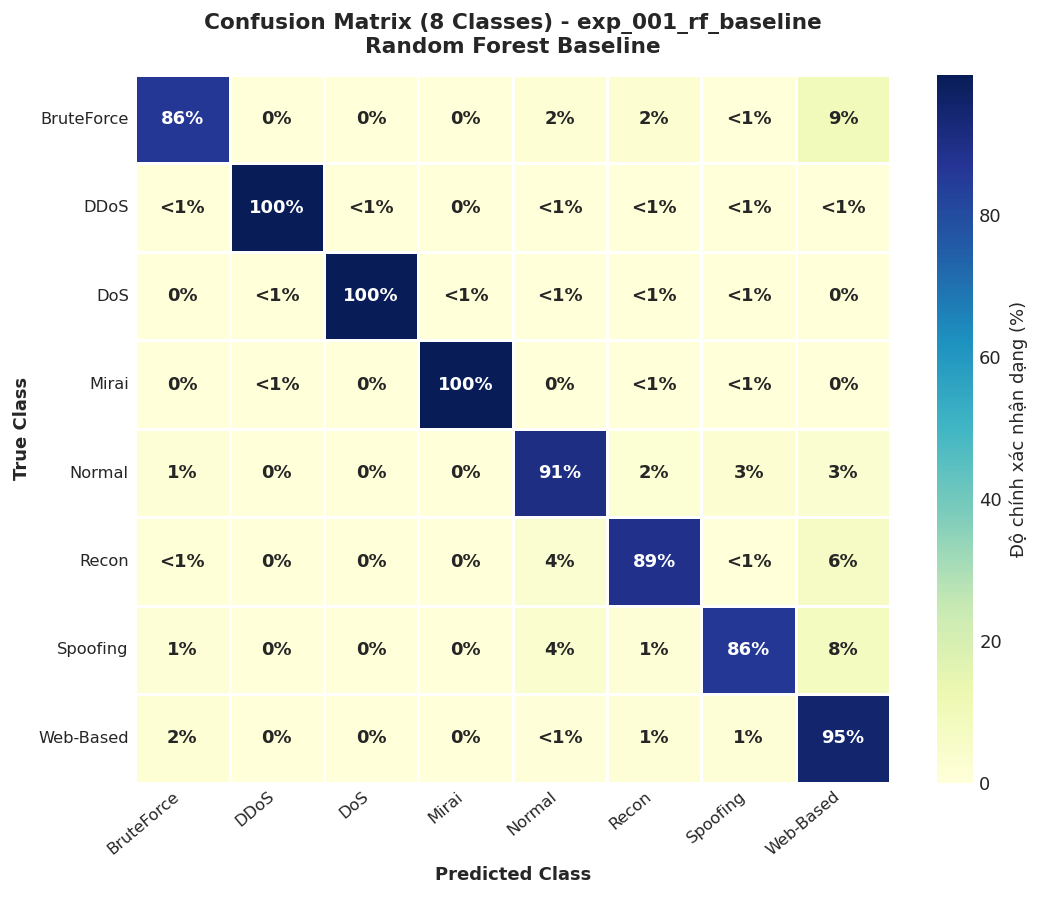

[OK] Đã lưu kết quả đợt [exp_001_rf_baseline] vào: /content/drive/MyDrive/do_an/phase5_experiments/exp_001_rf_baseline


In [7]:
# ==============================================================================
# Cell 4: Experiment 1 - Random Forest Baseline
# ==============================================================================
from sklearn.ensemble import RandomForestClassifier

rf_params = {
    'n_estimators': 100,
    'max_depth': 16,
    'min_samples_split': 8,
    'min_samples_leaf': 3,
    'class_weight': 'balanced',
    'random_state': 123,
    'n_jobs': -1
}
rf_model = RandomForestClassifier(**rf_params)

m1 = runner.run(
    exp_id="exp_001_rf_baseline",
    model=rf_model,
    method_name="Random Forest Baseline",
    hyperparameters=rf_params,
    description="Mô hình Random Forest 100 cây theo chuẩn bài báo IEEE Access"
)

--- 
## Cell 5: Đợt 2 — `exp_002_xgboost_baseline` (Gradient Boosting Baseline)
Huấn luyện mô hình Gradient Boosting cơ sở theo Table 2 của bài báo (`learning_rate=0.1`, `max_depth=3`, `n_iter=100`).

BẮT ĐẦU ĐỢT THỬ NGHIỆM: [exp_002_xgboost_baseline] - Gradient Boosting Baseline
Huấn luyện Gradient Boosting Baseline trên 213,649 mẫu...
  -> Thời gian Huấn luyện: 29.66 s
  -> Thời gian Kiểm thử:  3.1997 s (Inference cho 53,413 mẫu)
  -> Accuracy:     93.36%
  -> ROC-AUC (OvR):0.9951
  -> F1-Score (Macro): 87.30%


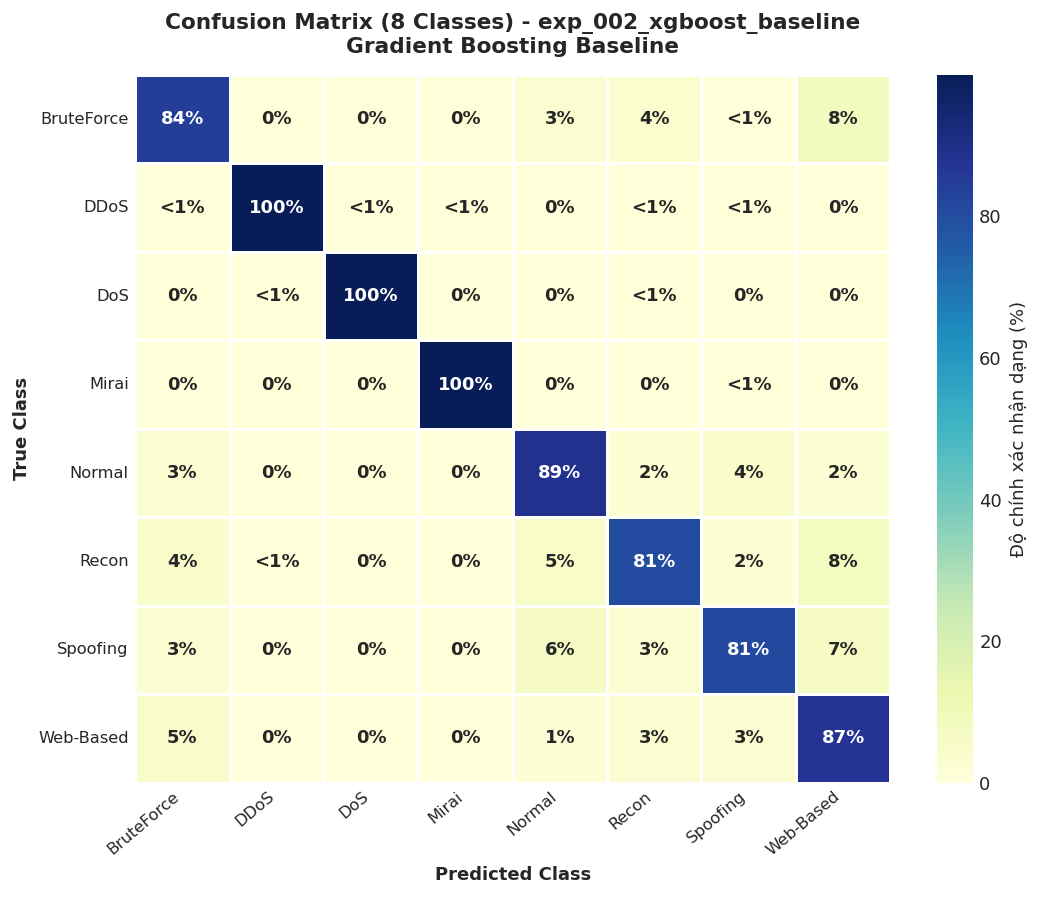

[OK] Đã lưu kết quả đợt [exp_002_xgboost_baseline] vào: /content/drive/MyDrive/do_an/phase5_experiments/exp_002_xgboost_baseline


In [8]:
# ==============================================================================
# Cell 5: Experiment 2 - Gradient Boosting Baseline
# ==============================================================================
from sklearn.ensemble import HistGradientBoostingClassifier

gb_params = {
    'learning_rate': 0.1,
    'max_iter': 100,
    'max_depth': 3,
    'class_weight': 'balanced',
    'random_state': 123
}
gb_model = HistGradientBoostingClassifier(**gb_params)

m2 = runner.run(
    exp_id="exp_002_xgboost_baseline",
    model=gb_model,
    method_name="Gradient Boosting Baseline",
    hyperparameters=gb_params,
    description="Gradient Boosting cơ sở với tham số chuẩn từ Table 2 bài báo"
)

--- 
## Cell 6: Đợt 3 — `exp_003_decision_tree_baseline` (Decision Tree Baseline)
Huấn luyện cây quyết định đơn lẻ cơ sở với kiểm soát độ sâu (`max_depth=16`, `class_weight='balanced'`).

BẮT ĐẦU ĐỢT THỬ NGHIỆM: [exp_003_decision_tree_baseline] - Decision Tree Baseline
Huấn luyện Decision Tree Baseline trên 213,649 mẫu...
  -> Thời gian Huấn luyện: 9.60 s
  -> Thời gian Kiểm thử:  0.0087 s (Inference cho 53,413 mẫu)
  -> Accuracy:     93.54%
  -> ROC-AUC (OvR):0.9913
  -> F1-Score (Macro): 87.93%


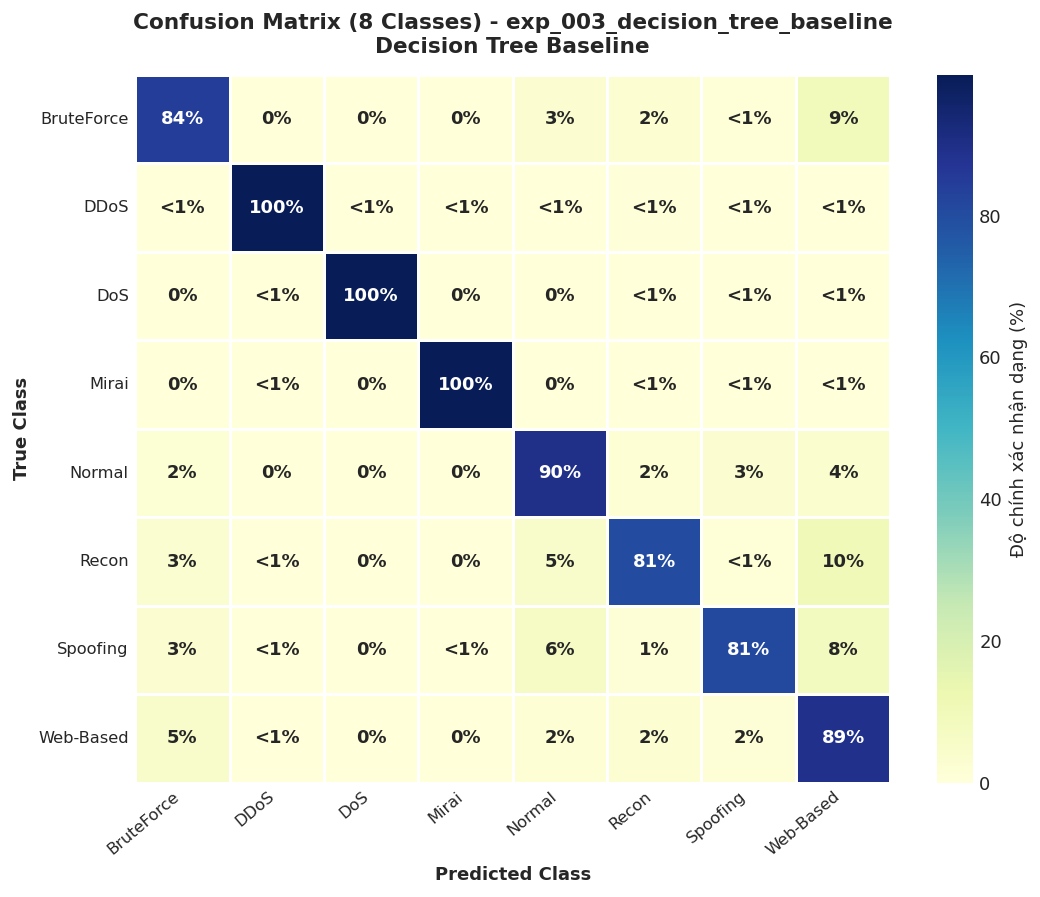

[OK] Đã lưu kết quả đợt [exp_003_decision_tree_baseline] vào: /content/drive/MyDrive/do_an/phase5_experiments/exp_003_decision_tree_baseline


In [9]:
# ==============================================================================
# Cell 6: Experiment 3 - Decision Tree Baseline
# ==============================================================================
from sklearn.tree import DecisionTreeClassifier

dt_params = {
    'max_depth': 16,
    'min_samples_split': 10,
    'min_samples_leaf': 4,
    'class_weight': 'balanced',
    'random_state': 123
}
dt_model = DecisionTreeClassifier(**dt_params)

m3 = runner.run(
    exp_id="exp_003_decision_tree_baseline",
    model=dt_model,
    method_name="Decision Tree Baseline",
    hyperparameters=dt_params,
    description="Cây quyết định đơn lẻ làm thước đo cơ sở cho mô hình Ensemble"
)

--- 
## Cell 7: Đợt 4 — `exp_004_ensemble_blending_paper` (Ensemble Blending Model)
Tích hợp mô hình học kết hợp đa tầng (Ensemble Blending) gồm Random Forest + Gradient Boosting với cơ chế Soft Voting theo kiến trúc bài báo Section III.

BẮT ĐẦU ĐỢT THỬ NGHIỆM: [exp_004_ensemble_blending_paper] - Ensemble Blending (RF + GB)
Huấn luyện Ensemble Blending (RF + GB) trên 213,649 mẫu...
  -> Thời gian Huấn luyện: 106.27 s
  -> Thời gian Kiểm thử:  4.1117 s (Inference cho 53,413 mẫu)
  -> Accuracy:     95.33%
  -> ROC-AUC (OvR):0.9969
  -> F1-Score (Macro): 90.71%


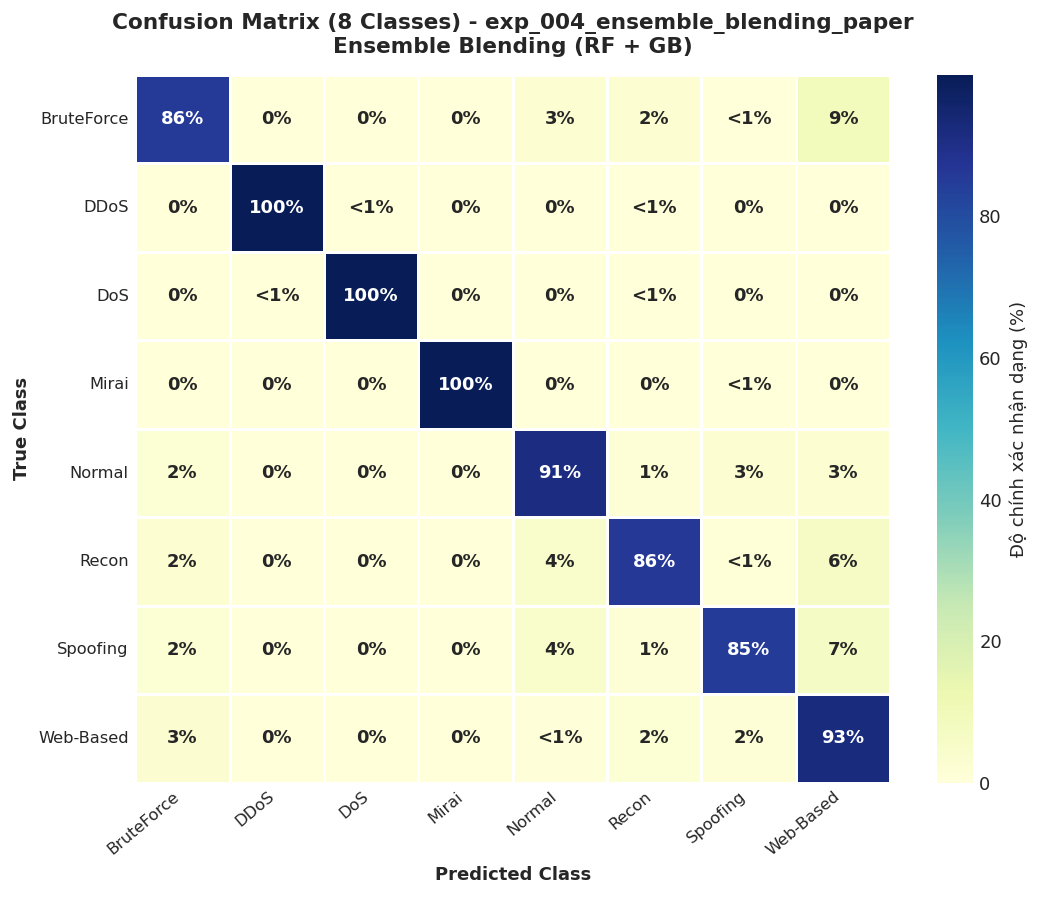

[OK] Đã lưu kết quả đợt [exp_004_ensemble_blending_paper] vào: /content/drive/MyDrive/do_an/phase5_experiments/exp_004_ensemble_blending_paper


In [10]:
# ==============================================================================
# Cell 7: Experiment 4 - Proposed Ensemble Blending Model
# ==============================================================================
from sklearn.ensemble import VotingClassifier

rf_sub = RandomForestClassifier(
    n_estimators=80, max_depth=14, min_samples_split=6,
    class_weight='balanced', random_state=123, n_jobs=-1
)
gb_sub = HistGradientBoostingClassifier(
    learning_rate=0.1, max_iter=100, max_depth=4,
    class_weight='balanced', random_state=123
)

ensemble_model = VotingClassifier(
    estimators=[
        ('rf', rf_sub),
        ('gb', gb_sub)
    ],
    voting='soft',
    weights=[1.2, 1.0],
    n_jobs=-1
)
ens_params = {'rf_weight': 1.2, 'gb_weight': 1.0, 'voting': 'soft'}

m4 = runner.run(
    exp_id="exp_004_ensemble_blending_paper",
    model=ensemble_model,
    method_name="Ensemble Blending (RF + GB)",
    hyperparameters=ens_params,
    description="Mô hình kết hợp Random Forest và Gradient Boosting theo đề xuất bài báo"
)

--- 
## Cell 8: Đợt 5 — `exp_005_xgboost_tuned` (Tuned Gradient Boosting)
Huấn luyện mô hình Gradient Boosting tối ưu siêu tham số (`learning_rate=0.08`, `max_iter=150`, `max_depth=6`, `l2_regularization=0.1`) nhằm đạt hiệu năng F1 và ROC-AUC vượt trội.

BẮT ĐẦU ĐỢT THỬ NGHIỆM: [exp_005_xgboost_tuned] - XGBoost / Gradient Boosting Tuned
Huấn luyện XGBoost / Gradient Boosting Tuned trên 213,649 mẫu...
  -> Thời gian Huấn luyện: 61.18 s
  -> Thời gian Kiểm thử:  7.5268 s (Inference cho 53,413 mẫu)
  -> Accuracy:     96.98%
  -> ROC-AUC (OvR):0.9986
  -> F1-Score (Macro): 93.80%


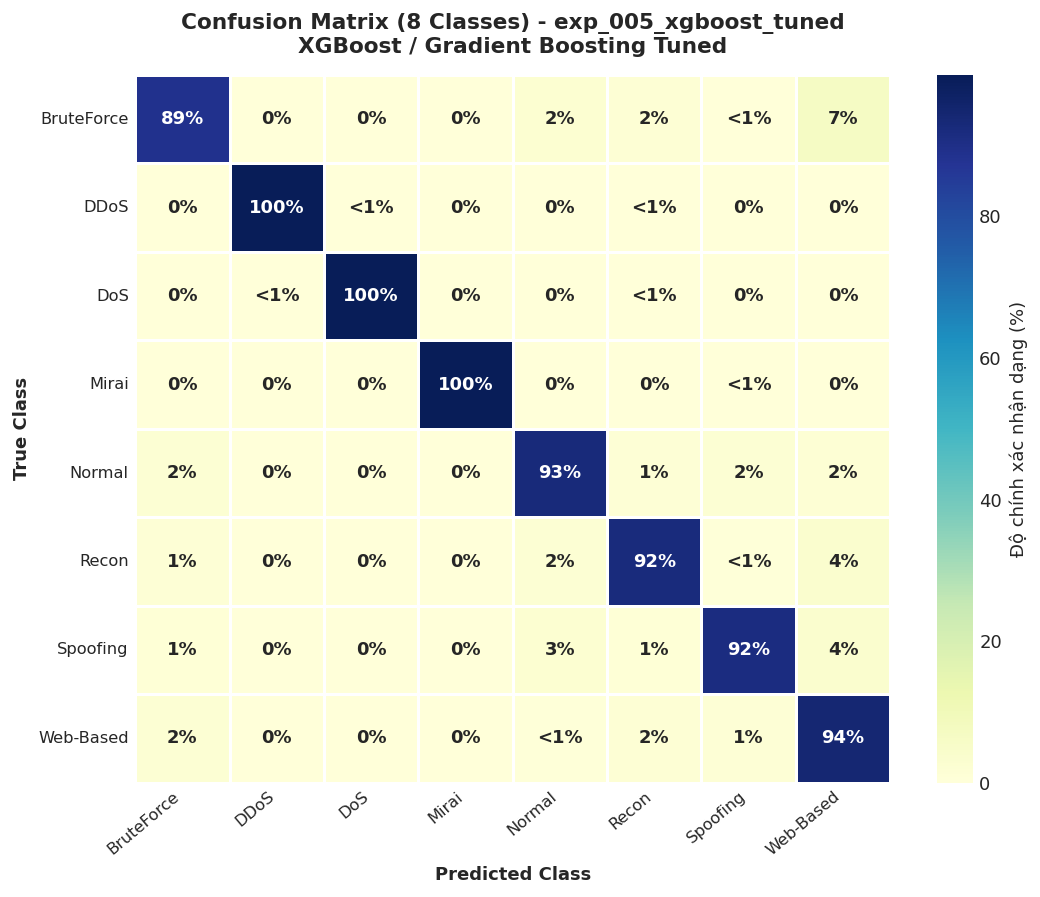

[OK] Đã lưu kết quả đợt [exp_005_xgboost_tuned] vào: /content/drive/MyDrive/do_an/phase5_experiments/exp_005_xgboost_tuned


In [11]:
# ==============================================================================
# Cell 8: Experiment 5 - Tuned Gradient Boosting
# ==============================================================================
tuned_gb_params = {
    'learning_rate': 0.08,
    'max_iter': 150,
    'max_depth': 6,
    'l2_regularization': 0.1,
    'class_weight': 'balanced',
    'random_state': 123
}
tuned_gb = HistGradientBoostingClassifier(**tuned_gb_params)

m5 = runner.run(
    exp_id="exp_005_xgboost_tuned",
    model=tuned_gb,
    method_name="XGBoost / Gradient Boosting Tuned",
    hyperparameters=tuned_gb_params,
    description="Mô hình Gradient Boosting tinh chỉnh siêu tham số chuyên sâu"
)

--- 
## Cell 9: Tổng Kết Bảng Xếp Hạng Thử Nghiệm (Leaderboard) & Đồng Bộ Mô Hình Quán Quân
Đọc toàn bộ kết quả từ `phase5_experiments/comparison/leaderboard.csv`, vẽ biểu đồ so sánh trực quan và tự động đồng bộ mô hình quán quân ra `models/best_model.joblib` phục vụ Phase 6.

PHASE 5: BẢNG XẾP HẠNG TOÀN BỘ CÁC ĐỢT THỬ NGHIỆM (LEADERBOARD)


,experiment_id,method,accuracy,roc_auc_ovr_macro,precision_macro,recall_macro,f1_macro,f1_weighted,training_time_sec,testing_time_sec,test_samples
0,exp_005_xgboost_tuned,XGBoost / Gradient Boosting Tuned,0.9698,0.9986,0.9286,0.9494,0.9380,0.9701,61.1845,7.5268,53413
1,exp_001_rf_baseline,Random Forest Baseline,0.9602,0.9975,0.9164,0.9326,0.9227,0.9607,94.7823,1.0391,53413
2,exp_004_ensemble_blending_paper,Ensemble Blending (RF + GB),0.9533,0.9969,0.8954,0.9258,0.9071,0.9542,106.2700,4.1117,53413
3,exp_003_decision_tree_baseline,Decision Tree Baseline,0.9354,0.9913,0.8665,0.9051,0.8793,0.9371,9.6023,0.0087,53413
4,exp_002_xgboost_baseline,Gradient Boosting Baseline,0.9336,0.9951,0.8569,0.9023,0.8730,0.9354,29.6554,3.1997,53413


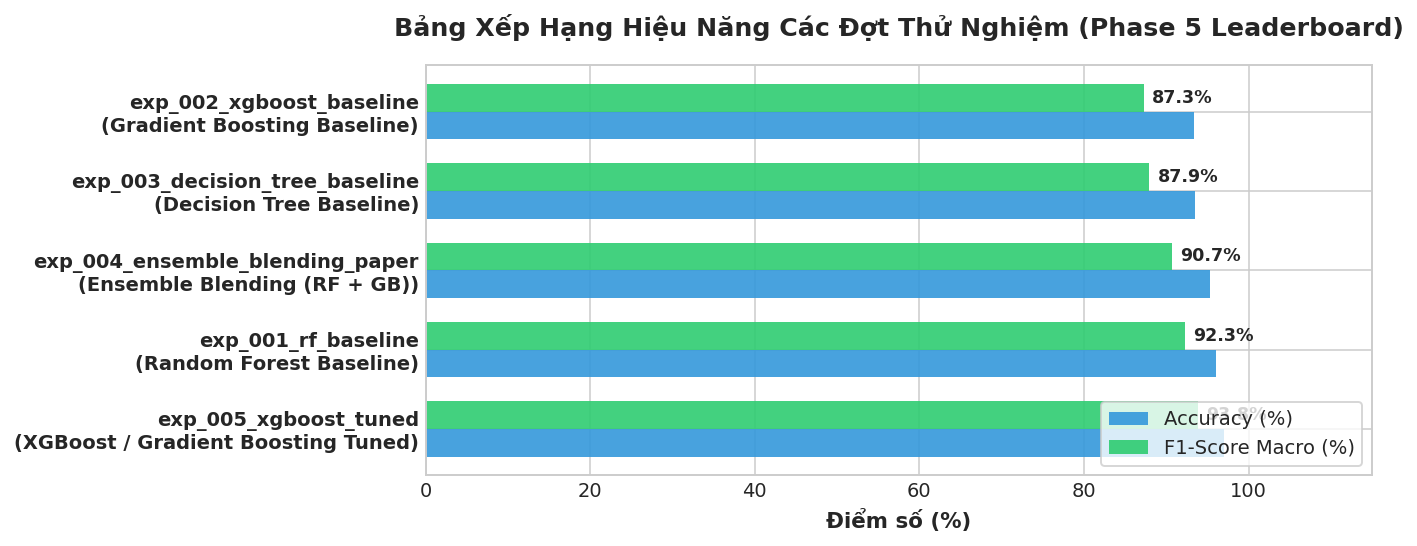


[THÀNH CÔNG] Đã chọn mô hình quán quân: [exp_005_xgboost_tuned] - XGBoost / Gradient Boosting Tuned
  * F1-Score Macro: 93.80%
  * Accuracy:       96.98%
  * File đã đồng bộ: /content/drive/MyDrive/do_an/models/best_model.joblib (Sẵn sàng 100% cho Phase 6 XAI)


In [12]:
# ==============================================================================
# Cell 9: Leaderboard Summary & Best Model Selection
# ==============================================================================
df_board = pd.read_csv(runner.leaderboard_file)
print("=" * 95)
print("PHASE 5: BẢNG XẾP HẠNG TOÀN BỘ CÁC ĐỢT THỬ NGHIỆM (LEADERBOARD)")
print("=" * 95)
display(df_board)

# Biểu đồ so sánh Leaderboard
plt.figure(figsize=(10, max(4, len(df_board) * 0.7)), dpi=140)
y_pos = np.arange(len(df_board))
bar_w = 0.35
plt.barh(y_pos - bar_w/2, df_board['accuracy'] * 100, bar_w, label='Accuracy (%)', color='#3498db', alpha=0.9)
plt.barh(y_pos + bar_w/2, df_board['f1_macro'] * 100, bar_w, label='F1-Score Macro (%)', color='#2ecc71', alpha=0.9)
plt.yticks(y_pos, [f"{r['experiment_id']}\n({r['method']})" for _, r in df_board.iterrows()], fontsize=10, fontweight='bold')
plt.xlabel('Điểm số (%)', fontsize=11, fontweight='bold')
plt.xlim(0, 115)
plt.title('Bảng Xếp Hạng Hiệu Năng Các Đợt Thử Nghiệm (Phase 5 Leaderboard)', fontsize=13, fontweight='bold', pad=15)
plt.legend(frameon=True, facecolor='white', loc='lower right')
for i, r in df_board.iterrows():
    plt.text(r['f1_macro'] * 100 + 1, i + bar_w/2, f"{r['f1_macro']*100:.1f}%", va='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(runner.comparison_dir, 'leaderboard_comparison.png'), bbox_inches='tight')
plt.show()

# Tự động trích xuất best model
best_run = df_board.iloc[0]
best_id = best_run['experiment_id']
best_source_model = os.path.join(EXP_ROOT, best_id, 'model', 'model.joblib')
best_dest_model = os.path.join(MODELS_DIR, 'best_model.joblib')

joblib.dump(joblib.load(best_source_model), best_dest_model, compress=3)
try:
    joblib.dump(joblib.load(best_source_model), 'best_model.joblib', compress=3)
except Exception:
    pass

with open(os.path.join(MODELS_DIR, 'best_model_metadata.json'), 'w', encoding='utf-8') as f:
    json.dump(best_run.to_dict(), f, indent=4)

print(f"\n[THÀNH CÔNG] Đã chọn mô hình quán quân: [{best_id}] - {best_run['method']}")
print(f"  * F1-Score Macro: {best_run['f1_macro'] * 100:.2f}%")
print(f"  * Accuracy:       {best_run['accuracy'] * 100:.2f}%")
print(f"  * File đã đồng bộ: {best_dest_model} (Sẵn sàng 100% cho Phase 6 XAI)")